In [2]:
import os
import re
import statistics
import sys
import tempfile
from multiprocessing.dummy import Pool
import anndata as ad
import celltypist
import cosg
import gseapy as gp
import leidenalg
import matplotlib.pyplot as plt
import muon as mu
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import scipy
import scipy.io as sio
import seaborn as sns
import sklearn
from joblib import Parallel, delayed
from tqdm import tqdm
import gc

sc.settings.n_jobs = 24
sc.settings.verbosity = 1
# Adjust Scanpy figure defaults
sc.settings.set_figure_params(
    dpi=100, fontsize=10, dpi_save=400, facecolor="white", figsize=(8, 8), format="png"
)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

import matplotlib as mpl
import matplotlib.font_manager as fm
mpl.rcParams['pdf.fonttype'] = 42
fm.fontManager.addfont("fonts/arial.ttf")
mpl.rcParams['font.family'] = 'arial'
mpl.rcParams['lines.linewidth'] = 0.5

/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/home/liyanguo/anaconda3/envs/R45/lib/python3.13/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [3]:
def check_dict_duplicates(dict):
    seen = set()
    dup = any(item in seen or seen.add(item) for lst in dict.values() for item in lst)
    if dup == False:
        return "无重复"
    else:
        return "有重复"

In [4]:
def filename_cell_type(filename):
    cell_type = re.sub(" ", "_", filename)
    cell_type = re.sub("[+]", "pos", cell_type)
    cell_type = re.sub("[-]", "_", cell_type)
    cell_type = re.sub("[/]", "_", cell_type)
    return cell_type

In [5]:
finnal_path = "/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Finnal/"

# 1. Read the well-annotated cell labels obtained from different stages.

## Celltype_L2_L3_Refine

In [5]:
celltypes = [
    "Basophil",
    "CEACAM8_Pos_Neutrophil",
    "DC",
    "HSPC",
    "iNKT",
    "Mast",
    "Monocyte",
    "NK",
    "Non_NK_ILC",
    "Plasma",
    "Platelet",
]

In [6]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 11/11 [00:10<00:00,  1.07it/s]


In [7]:
Celltype_L2_L3_Refine_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [8]:
Celltype_L2_L3_Refine_Finnal_indices_dict["Refined_label"] = (
    Celltype_L2_L3_Refine_Finnal_indices_dict["Celltype_L2_L3_Refine"]
)

In [9]:
Celltype_L2_L3_Refine_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    9017890
Name: count, dtype: int64

## Celltype_L3_L4_Refine

In [10]:
celltypes = [
    "DnT",
    "Memory_B",
    "NaiveB",
    "NaiveCD4",
    "CEACAM8_Neg_Neutrophil",
]

In [11]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 5/5 [00:46<00:00,  9.38s/it]


In [12]:
Celltype_L3_L4_Refine_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [13]:
Celltype_L3_L4_Refine_Finnal_indices_dict["Refined_label"] = (
    Celltype_L3_L4_Refine_Finnal_indices_dict["Celltype_L3_L4_Refine"]
)

In [14]:
Celltype_L3_L4_Refine_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    33099544
Name: count, dtype: int64

## Celltype_L4_L5_Refine

In [15]:
celltypes = ["AtypicalB", "NaiveCD8"]

In [16]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 2/2 [00:02<00:00,  1.06s/it]


In [17]:
Celltype_L4_L5_Refine_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [18]:
Celltype_L4_L5_Refine_Finnal_indices_dict["Celltype_L4_L5_Refine"].value_counts()

Celltype_L4_L5_Refine
Naïve CD8+ T cells                    1235329
CD27+ IgD+ atypical memory B cells      28712
CD27- IgD- atypical memory B cells      14713
Atypical naïve B cells                  11697
CD27+ IgD- atypical memory B cells       8935
Name: count, dtype: int64

In [19]:
Celltype_L4_L5_Refine_Finnal_indices_dict["Refined_label"] = (
    Celltype_L4_L5_Refine_Finnal_indices_dict["Celltype_L4_L5_Refine"]
)

In [20]:
Celltype_L4_L5_Refine_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    1299386
Name: count, dtype: int64

## Celltype_L4_L5_Refine_R2

In [21]:
celltypes = ["CD8Tcm", "TemCD8"]

In [22]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 2/2 [00:05<00:00,  2.61s/it]


In [23]:
Celltype_L4_L5_Refine_R2_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [24]:
Celltype_L4_L5_Refine_R2_Finnal_indices_dict["Celltype_L4_L5_Refine_R2"].value_counts()

Celltype_L4_L5_Refine_R2
CD8+ Temra           1134447
GZMB+ CD8+ Tem       1105417
HLA-DRhi CD8+ Tem     747000
GZMK+ CD8+ Tem        666573
CCR4+ CD8+ Tcm        103039
vNKT                   80176
CCR4- CD8+ Tcm         32040
Name: count, dtype: int64

In [25]:
Celltype_L4_L5_Refine_R2_Finnal_indices_dict["Refined_label"] = (
    Celltype_L4_L5_Refine_R2_Finnal_indices_dict["Celltype_L4_L5_Refine_R2"]
)

In [26]:
Celltype_L4_L5_Refine_R2_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    3868692
Name: count, dtype: int64

## Celltype_L4_L5_Refine_R3

In [27]:
celltypes = [
    "TregCD4",
    "TregCD8",
    "Tfh_Tcm",
    "CytotoxicCD4",
    "MAIT",
    "Vd1",
    "Vd2",
]

In [28]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 7/7 [00:04<00:00,  1.49it/s]


In [29]:
Celltype_L4_L5_Refine_R3_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [30]:
Celltype_L4_L5_Refine_R3_Finnal_indices_dict["Celltype_L4_L5_Refine_R3"].value_counts()

Celltype_L4_L5_Refine_R3
Tfh                                        1125265
GZMB+ CD4+ terminal effector T cells        717617
GZMB+ Vδ2+ T cells                          630298
CD27+ MAIT                                  245385
Memory CD4+ Treg                            239193
GZMK+ Vδ2+ T cells                          224338
Naïve CD4+ Treg                              76314
CD62Lhi GZMK+ Vδ2+ T cells                   39016
CD27- MAIT                                   34101
KLRB1+ CD4+ Treg                             31848
Naïve Vδ1+ T cells                           14980
HLA-DRhi CD4+ Treg                           14793
CD4+ Temra                                   14511
HLA-DRhi CD4+ terminal effector T cells      12670
GZMK+ effector Vδ1+ T cells                  10359
SOX4+ Vδ1+ T cells                            6557
KLRC2+ effector Vδ1+ T cells                  4313
CD279+ SOX4+ Vδ1+ T cells                     3356
CD8+ Treg                                     2827
CD56+ 

In [31]:
Celltype_L4_L5_Refine_R3_Finnal_indices_dict["Refined_label"] = (
    Celltype_L4_L5_Refine_R3_Finnal_indices_dict["Celltype_L4_L5_Refine_R3"]
)

In [32]:
Celltype_L4_L5_Refine_R3_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    3448496
Name: count, dtype: int64

## Celltype_L4_L5_Refine_R5

In [33]:
celltypes = [
    "Th1",
    "Th22",
    "Th2",
    "Th17",
    "Th1_Th17",
    "ProliferativeT",
]

In [34]:
Finnal_indices_dict = []
for i in tqdm(celltypes):
    indices = pd.read_csv(f"{finnal_path}{i}/Finnal_indices_{i}.csv", index_col=0)
    Finnal_indices_dict.append(indices)

100%|██████████| 6/6 [00:01<00:00,  3.34it/s]


In [35]:
Celltype_L4_L5_Refine_R5_Finnal_indices_dict = pd.concat(Finnal_indices_dict)

In [36]:
Celltype_L4_L5_Refine_R5_Finnal_indices_dict["Celltype_L4_L5_Refine_R5"].value_counts()

Celltype_L4_L5_Refine_R5
CD27+ Th17                              488849
Th1/Th17                                315375
CD27+ Th1                                97975
Th2                                      86571
Tfh                                      86404
CD27- Th17                               76124
Th22                                     64229
CD27- Th1                                45604
Proliferative help memory T cells        23240
Proliferative CD8+ memory T cells        13607
Proliferative CD4+ Treg                   9026
Proliferative DN T cells                   755
Proliferative cytotoxic CD4+ T cells       313
Proliferative Vδ2+ T cells                 203
Name: count, dtype: int64

In [37]:
Celltype_L4_L5_Refine_R5_Finnal_indices_dict["Refined_label"] = (
    Celltype_L4_L5_Refine_R5_Finnal_indices_dict["Celltype_L4_L5_Refine_R5"]
)

In [38]:
Celltype_L4_L5_Refine_R5_Finnal_indices_dict["Refined_label"].isna().value_counts()

Refined_label
False    1308275
Name: count, dtype: int64

## Concat all dict

In [39]:
Final_cell_label = pd.concat(
    [
        Celltype_L2_L3_Refine_Finnal_indices_dict,
        Celltype_L3_L4_Refine_Finnal_indices_dict,
        Celltype_L4_L5_Refine_Finnal_indices_dict,
        Celltype_L4_L5_Refine_R2_Finnal_indices_dict,
        Celltype_L4_L5_Refine_R3_Finnal_indices_dict,
        Celltype_L4_L5_Refine_R5_Finnal_indices_dict,
    ]
)

In [40]:
Final_cell_label["Refined_label"].isna().value_counts()

Refined_label
False    52042283
Name: count, dtype: int64

In [41]:
Final_cell_label["Refined_label"].value_counts()

Refined_label
Core NDNs                                  11531713
MT-ATP6- MT-CO2- NDNs                       3216608
IRF1- GBP2- NDNs                            3043463
Naïve CD4+ T cells                          2944753
Core classical monocytes                    2402622
Adaptive NK cells                           2352029
CD56dim NK cells                            2312983
VIM- FLNA- NDNs                             2278620
ALPL- MARCKS- NDNs                          2254723
RGS2- NDNs                                  2194221
IFIT2- RNF213- NDNs                         1407623
CXCL8- PTGS2+ NDNs                          1263888
Naïve CD8+ T cells                          1235329
Tfh                                         1211669
FOS- NDNs                                   1209145
CD8+ Temra                                  1134447
GZMB+ CD8+ Tem                              1105417
Naïve B cells                               1036706
HLA-DRhi CD8+ Tem                            74700

# 2. Genegrate Classification

## Classification_L4

In [42]:
Final_cell_label["Classification_L4"] = Final_cell_label["Refined_label"]

## Classification_L3

In [43]:
cell_dict = {
    "Basophils": [
        "Basophils",
    ],
    "cDC1": ["cDC1"],
    "cDC2": ["CD14+ cDC2", "CD1C+ cDC2"],
    "ASDC": ["ASDC"],
    "pDCs": ["pDCs"],
    "LAMP3+ DC": ["LAMP3+ DC"],
    "Mast cells": ["MC/MCP"],
    "HSPC": [
        "MEP",
        "CILCP",
        "MkP",
        "CLP",
        "HSC/MPP",
    ],
    "LDNs": [
        "Proliferative mLDNs",
        "MPO+ mLDNs",
        "MMP8+ CD177+ mLDNs",
        "Proliferative iLDNs",
        "MPO+ CD177- iLDNs",
        "MPO- CD177- iLDNs",
        "CD177int iLDNs",
        "MMP8+ CD177+ iLDNs",
        "MMP9+ CD177+ iLDNs",
    ],
    "NDNs": [
        "Core NDNs",
        "MT-ATP6- MT-CO2- NDNs",
        "IRF1- GBP2- NDNs",
        "VIM- FLNA- NDNs",
        "ALPL- MARCKS- NDNs",
        "RGS2- NDNs",
        "IFIT2- RNF213- NDNs",
        "CXCL8- PTGS2+ NDNs",
        "FOS- NDNs",
    ],
    ##
    "Classical monocytes": [
        "Core classical monocytes",
        "GBP1+ classical monocytes",
        "ISG+ classical monocytes",
    ],
    "Intermediate monocytes": [
        "Intermediate monocytes",
    ],
    "Non-classical Monocytes": [
        "Non-classical monocytes",
    ],
    ##
    "DN T cells": [
        "DN T cells",
        "Proliferative DN T cells",
    ],
    "Naïve CD4+ T cells": ["Naïve CD4+ T cells"],
    "Naïve CD8+ T cells": ["Naïve CD8+ T cells"],
    "Help memory T cells": [
        "CD27- Th17",
        "CD27+ Th17",
        "CD27- Th1",
        "CD27+ Th1",
        "Th22",
        "Th2",
        "Th1/Th17",
        "Tfh",
        "Proliferative help memory T cells",
    ],
    "CD8+ Treg": ["CD8+ Treg"],
    "CD4+ Treg": [
        "Naïve CD4+ Treg",
        "Memory CD4+ Treg",
        "HLA-DRhi CD4+ Treg",
        "KLRB1+ CD4+ Treg",
        "Proliferative CD4+ Treg",
    ],
    "Cytotoxic CD4+ T cells": [
        "HLA-DRhi CD4+ terminal effector T cells",
        "CD4+ Temra",
        "GZMB+ CD4+ terminal effector T cells",
        "Proliferative cytotoxic CD4+ T cells",
    ],
    "CD8+ Tcm": [
        "CCR4- CD8+ Tcm",
        "CCR4+ CD8+ Tcm",
    ],
    "CD8+ Tem": [
        "GZMK+ CD8+ Tem",
        "HLA-DRhi CD8+ Tem",
        "GZMB+ CD8+ Tem",
        "CD8+ Temra",
        "Proliferative CD8+ memory T cells",
    ],
    "Vδ1+ T cells": [
        "Naïve Vδ1+ T cells",
        "SOX4+ Vδ1+ T cells",
        "CD279+ SOX4+ Vδ1+ T cells",
        "GZMK+ effector Vδ1+ T cells",
        "KLRC2+ effector Vδ1+ T cells",
    ],
    "Vδ2+ T cells": [
        "CD62Lhi GZMK+ Vδ2+ T cells",
        "GZMK+ Vδ2+ T cells",
        "GZMB+ Vδ2+ T cells",
        "Proliferative Vδ2+ T cells",
    ],
    "MAIT": ["CD27+ MAIT", "CD27- MAIT", "CD56+ MAIT"],
    "NKT": ["iNKT", "vNKT"],
    ##
    "Naïve B cells": ["Naïve B cells"],
    "Memory B cells": [
        "Early memory B cells",
        "Non-switched memory B cells",
        "Switched Memory B cells",
        "CD95 memory B cells",
    ],
    "Atypical B cells": [
        "Atypical naïve B cells",
        "CD27+ IgD+ atypical memory B cells",
        "CD27+ IgD- atypical memory B cells",
        "CD27- IgD- atypical memory B cells",
    ],
    "Plasma cells": [
        "IGLL5hi Plasma cells",
        "Plamsablasts",
        "IGKChi Plasma cells",
    ],
    ##
    "NK cells": [
        "Proliferative NK cells",
        "CD56bright NK cells",
        "CD56dim NK cells",
        "Adaptive NK cells",
    ],
    "Non-NK ILCs": ["ILC2", "ILCP"],
    ##
    "Platelets": ["Platelets"],
}

In [44]:
cell_dict.values()

dict_values([['Basophils'], ['cDC1'], ['CD14+ cDC2', 'CD1C+ cDC2'], ['ASDC'], ['pDCs'], ['LAMP3+ DC'], ['MC/MCP'], ['MEP', 'CILCP', 'MkP', 'CLP', 'HSC/MPP'], ['Proliferative mLDNs', 'MPO+ mLDNs', 'MMP8+ CD177+ mLDNs', 'Proliferative iLDNs', 'MPO+ CD177- iLDNs', 'MPO- CD177- iLDNs', 'CD177int iLDNs', 'MMP8+ CD177+ iLDNs', 'MMP9+ CD177+ iLDNs'], ['Core NDNs', 'MT-ATP6- MT-CO2- NDNs', 'IRF1- GBP2- NDNs', 'VIM- FLNA- NDNs', 'ALPL- MARCKS- NDNs', 'RGS2- NDNs', 'IFIT2- RNF213- NDNs', 'CXCL8- PTGS2+ NDNs', 'FOS- NDNs'], ['Core classical monocytes', 'GBP1+ classical monocytes', 'ISG+ classical monocytes'], ['Intermediate monocytes'], ['Non-classical monocytes'], ['DN T cells', 'Proliferative DN T cells'], ['Naïve CD4+ T cells'], ['Naïve CD8+ T cells'], ['CD27- Th17', 'CD27+ Th17', 'CD27- Th1', 'CD27+ Th1', 'Th22', 'Th2', 'Th1/Th17', 'Tfh', 'Proliferative help memory T cells'], ['CD8+ Treg'], ['Naïve CD4+ Treg', 'Memory CD4+ Treg', 'HLA-DRhi CD4+ Treg', 'KLRB1+ CD4+ Treg', 'Proliferative CD4+ T

In [45]:
check_dict_duplicates(cell_dict)

'无重复'

In [46]:
unqieu_labels = Final_cell_label["Classification_L4"].unique()
all_items = []
for values in cell_dict.values():
    all_items.extend(values)

In [47]:
for i in all_items:
    if not i in unqieu_labels:
        print(f"{i} not exist")

In [48]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(Final_cell_label["Classification_L4"]).isin(cell_dict[i])
    Final_cell_label.loc[ind, "Classification_L3"] = i

In [49]:
Final_cell_label["Classification_L3"].isna().value_counts()

Classification_L3
False    52042283
Name: count, dtype: int64

In [50]:
Final_cell_label["Classification_L3"].value_counts()

Classification_L3
NDNs                       28400004
NK cells                    4921908
CD8+ Tem                    3667044
Naïve CD4+ T cells          2944753
Classical monocytes         2767127
Help memory T cells         2409636
Naïve CD8+ T cells          1235329
Naïve B cells               1036706
Vδ2+ T cells                 893855
Cytotoxic CD4+ T cells       745111
Memory B cells               713651
Non-classical Monocytes      510244
CD4+ Treg                    371174
Intermediate monocytes       303118
MAIT                         280241
cDC2                         205167
CD8+ Tcm                     135079
LDNs                          89517
pDCs                          86987
NKT                           80981
Atypical B cells              64057
Vδ1+ T cells                  39565
Plasma cells                  36878
Basophils                     34204
HSPC                          18927
Non-NK ILCs                   17562
DN T cells                     8276
cDC1      

## Classification_L2

In [51]:
cell_dict = {
    "CD4+ T cells": [
        "Naïve CD4+ T cells",
        "Cytotoxic CD4+ T cells",
        "Help memory T cells",
        "CD4+ Treg",
    ],  # CD8- CD4+
    "Non-MAIT/NKT CD8+ T cells": [
        "CD8+ Tcm",
        "CD8+ Tem",
        "Naïve CD8+ T cells",
        "CD8+ Treg",
    ],  # CD8+ CD4-
    "MAIT": ["MAIT"],  # CD8+
    "NKT": ["NKT"],  # vNKT CD8+/- CD4+/-
    "γδ T cells": ["Vδ2+ T cells", "Vδ1+ T cells"],
    "DN T cells": ["DN T cells"],
    "ILCs": ["NK cells", "Non-NK ILCs"],
    "B cells": ["Naïve B cells", "Plasma cells", "Memory B cells", "Atypical B cells"],
    "DC": ["cDC1", "cDC2", "ASDC", "pDCs", "LAMP3+ DC"],
    "Monocytes": [
        "Classical monocytes",
        "Intermediate monocytes",
        "Non-classical Monocytes",
    ],  # 这里和上级改变了
    "Granulocytes": ["LDNs", "NDNs", "Mast cells", "Basophils"],
    "HSPC": ["HSPC"],
    "Platelets": ["Platelets"],
}

In [52]:
check_dict_duplicates(cell_dict)

'无重复'

In [53]:
unqieu_labels = Final_cell_label["Classification_L3"].unique()
all_items = []
for values in cell_dict.values():
    all_items.extend(values)

In [54]:
for i in all_items:
    if not i in unqieu_labels:
        print(f"{i} not exist")

In [55]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(Final_cell_label["Classification_L3"]).isin(cell_dict[i])
    Final_cell_label.loc[ind, "Classification_L2"] = i

In [56]:
Final_cell_label["Classification_L2"].isna().value_counts()

Classification_L2
False    52042283
Name: count, dtype: int64

In [57]:
Final_cell_label["Classification_L2"].value_counts()

Classification_L2
Granulocytes                 28525525
CD4+ T cells                  6470674
Non-MAIT/NKT CD8+ T cells     5040279
ILCs                          4939470
Monocytes                     3580489
B cells                       1851292
γδ T cells                     933420
DC                             305272
MAIT                           280241
NKT                             80981
HSPC                            18927
DN T cells                       8276
Platelets                        7437
Name: count, dtype: int64

## Classification_L1

In [58]:
cell_dict = {
    "T cells": [
        "CD4+ T cells",
        "Non-MAIT/NKT CD8+ T cells",
        "MAIT",
        "NKT",
        "γδ T cells",
        "DN T cells",
    ],
    "B cells": ["B cells"],
    "ILCs": ["ILCs"],
    "Myeloid cells": ["Granulocytes", "Monocytes", "DC"],
    "HSPC": [
        "HSPC",
    ],
    "Platelets": ["Platelets"],
}

In [59]:
check_dict_duplicates(cell_dict)

'无重复'

In [60]:
unqieu_labels = Final_cell_label["Classification_L2"].unique()
all_items = []
for values in cell_dict.values():
    all_items.extend(values)

In [61]:
for i in all_items:
    if not i in unqieu_labels:
        print(f"{i} not exist")

In [62]:
# Generate new assignments
for i in cell_dict.keys():
    ind = pd.Series(Final_cell_label["Classification_L2"]).isin(cell_dict[i])
    Final_cell_label.loc[ind, "Classification_L1"] = i

In [63]:
Final_cell_label["Classification_L1"].isna().value_counts()

Classification_L1
False    52042283
Name: count, dtype: int64

In [64]:
Final_cell_label["Classification_L1"].value_counts()

Classification_L1
Myeloid cells    32411286
T cells          12813871
ILCs              4939470
B cells           1851292
HSPC                18927
Platelets            7437
Name: count, dtype: int64

In [65]:
Final_cell_label.shape

(52042283, 19)

## Leveraging cell proportion data alongside clinical information, we identified and removed several abnormal samples.

In [66]:
SampleID_to_remove = [
    "D0144_Rep1",
    "D0144_Rep2",
    "D0378_Rep1",
    "D0378_Rep2",
    "D0242_M_Rep1",
    "D0242_M_Rep2",
]

In [67]:
mask = Final_cell_label.index.str.contains(
    "D0144_Rep1|D0144_Rep2|D0378_Rep1|D0378_Rep2|D0242_M_Rep1|D0242_M_Rep2"
)
result = Final_cell_label[~mask]

## Del columns

In [69]:
result = result[
    [
        "Classification_L4",
        "Classification_L3",
        "Classification_L2",
        "Classification_L1",
        "leiden_cluster",
        'UMAP_1',
        'UMAP_2'
    ]
]

In [71]:
result.to_csv(
    "/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label.csv"
)

In [72]:
counts = (
    result.groupby(
        [
            "Classification_L1",
            "Classification_L2",
            "Classification_L3",
            "Classification_L4",
        ]
    )
    .size()
    .reset_index(name="Cell_counts")
)

In [73]:
counts.to_csv(
    "/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label_counts.csv"
)

## cell type Map file

In [74]:
mapfile = result[
    ["Classification_L4", "Classification_L3", "Classification_L2", "Classification_L1"]
].drop_duplicates()

In [75]:
mapfile.to_excel("/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/map_file.xlsx")

# 3. Full and Subtype Count Data Generate

## 3.1 Read cell type label

In [7]:
Final_cell_label = pd.read_csv(
    "/home/liyanguo/MyImmuCell/05_MyImmuCell_subpopulation/Final_cell_label.csv",
    index_col=0,
)
Final_cell_label.shape

(51898839, 7)

## 3.2 Full dataset
#recommond not join cell label to adata

In [7]:
def merge_datasets(files_dict, out_file, label="dataset"):
    ad.experimental.concat_on_disk(files_dict, out_file, label=label)
    return sc.read_h5ad(out_file)

In [8]:
# 1 hour
merged_scRNA = merge_datasets(
    {
        "adata_high": "/home/liyanguo/MyImmuCell/02_Read_QC/scRNA_MyImmuCell_high_nCount_RNA.h5ad",
        "adata_low": "/home/liyanguo/MyImmuCell/02_Read_QC/scRNA_MyImmuCell_low_nCount_RNA.h5ad",
    },
    "/home/liyanguo/MyImmuCell/00_code_MyImmuCell/merged_scRNA.h5ad",
)

In [9]:
# 10 min
merged_scADT = merge_datasets(
    {
        "adata_high": "/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scADT_MyImmuCell_high_nCount_RNA.h5ad",
        "adata_low": "/home/liyanguo/MyImmuCell/04_MyImmuCell_TOTALVI/scADT_MyImmuCell_low_nCount_RNA.h5ad",
    },
    "/home/liyanguo/MyImmuCell/00_code_MyImmuCell/merged_scADT.h5ad",
)

In [10]:
# Unfiltered(not QC)
merged_scRNA

AnnData object with n_obs × n_vars = 69161759 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset'

In [11]:
# Filtered(QC)
merged_scADT

AnnData object with n_obs × n_vars = 62614719 × 30
    obs: 'orig.ident', 'SampleID', 'DonorID', 'Batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'High_quality', 'doublets_by_markers', 'L1_leiden_TOTALVI_2', 'L1_leiden_TOTALVI_3', 'L1_leiden_TOTALVI_4', 'dataset'
    obsm: 'X_TOTALVI', 'X_umap'
    layers: 'clr', 'denoised_protein', 'dsb', 'protein_foreground_prob'

In [12]:
del merged_scADT.obs["L1_leiden_TOTALVI_2"]
del merged_scADT.obs["L1_leiden_TOTALVI_3"]
del merged_scADT.obs["L1_leiden_TOTALVI_4"]

In [13]:
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset"
os.makedirs(path, exist_ok=True)

In [14]:
adata = merged_scRNA[Final_cell_label.index]
adata.write(f"{path}/Full_dataset_scRNA_count.h5ad", compression="gzip")

In [15]:
adata

View of AnnData object with n_obs × n_vars = 51898839 × 38606
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset'

In [16]:
adt = merged_scADT[Final_cell_label.index]
del (
    adt.layers["denoised_protein"],
    adt.layers["protein_foreground_prob"],
    adt.layers["clr"],
    adt.layers["dsb"],
)
adt.write(f"{path}/Full_dataset_scADT_count.h5ad", compression="gzip")

In [17]:
adt

AnnData object with n_obs × n_vars = 51898839 × 30
    obs: 'orig.ident', 'SampleID', 'DonorID', 'Batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'High_quality', 'doublets_by_markers', 'dataset'
    obsm: 'X_TOTALVI', 'X_umap'

In [18]:
%%bash
rm /home/liyanguo/MyImmuCell/00_code_MyImmuCell/merged_scRNA.h5ad
rm /home/liyanguo/MyImmuCell/00_code_MyImmuCell/merged_scADT.h5ad

MAIT:HVG (280148, 2000) done.


In [19]:
(adata.obs.index == Final_cell_label.index).all()

np.True_

In [20]:
(adt.obs.index == Final_cell_label.index).all()

np.True_

### 3.2.1 Read Full data

In [6]:
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset"

adata = sc.read_h5ad(f"{path}/Full_dataset_scRNA_count.h5ad")
adt = sc.read_h5ad(f"{path}/Full_dataset_scADT_count.h5ad")

## 3.3 Save counts by cell type

In [7]:
def save_counts_and_process(
    adata,
    adt,
    Final_cell_label,
    cell_type,
    classification="Classification_L3",
    exclude_genes_file=None,
    HVG=True,
):

    filename = filename_cell_type(cell_type)
    path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{classification}/{filename}"
    os.makedirs(path, exist_ok=True)

    indices = Final_cell_label.query(f"{classification} == '{cell_type}'").index
    adata_subset = adata[indices]
    adt_subset = adt[indices]

    # Save scRNA/scADT counts
    adata_subset.write(f"{path}/{filename}_scRNA_count.h5ad", compression="gzip")
    adt_subset.write(f"{path}/{filename}_scADT_count.h5ad", compression="gzip")

    Final_cell_label.loc[indices].to_csv(f"{path}/{filename}_indices_labels.csv")

    # Process HVG
    if HVG:
        sc.pp.highly_variable_genes(
            adata_subset, flavor="seurat_v3", n_top_genes=2000, subset=True
        )
        
    if exclude_genes_file:
        gene_exclude = (
            pd.read_table(exclude_genes_file, header=None).iloc[:, 0].tolist()
        )
    else:
        gene_exclude = None
        
    if gene_exclude:
        adata_subset = adata_subset[
            :, ~adata_subset.var_names.isin(gene_exclude)
        ]
    adata_subset.write(f"{path}/{filename}_scRNA_count_HVG.h5ad", compression="gzip")

    print(f"{cell_type}:HVG {adata_subset.shape} done.")
    del adata_subset, adt_subset

### Classification_L3

In [8]:
unqieu_labels = np.array(Final_cell_label["Classification_L3"].unique())
unqieu_labels

array(['Basophils', 'LDNs', 'cDC1', 'LAMP3+ DC', 'cDC2', 'ASDC', 'pDCs',
       'HSPC', 'NKT', 'Mast cells', 'Classical monocytes',
       'Intermediate monocytes', 'Non-classical Monocytes', 'NK cells',
       'Non-NK ILCs', 'Plasma cells', 'Memory B cells', 'Platelets',
       'DN T cells', 'Naïve B cells', 'Naïve CD4+ T cells', 'NDNs',
       'Atypical B cells', 'Naïve CD8+ T cells', 'CD8+ Tcm', 'CD8+ Tem',
       'CD4+ Treg', 'CD8+ Treg', 'Help memory T cells',
       'Cytotoxic CD4+ T cells', 'MAIT', 'Vδ1+ T cells', 'Vδ2+ T cells'],
      dtype=object)

In [9]:
unqieu_labels = ["Plasma cells", "Memory B cells", "Naïve B cells", "Atypical B cells"]
args = [
    (
        adata,
        adt,
        Final_cell_label,
        cell_type,
        "Classification_L3",
        "1_annotation/BCR_gene.txt",
        True,
    )
    for cell_type in unqieu_labels
]
with Pool(4) as pl:
    pl.starmap(save_counts_and_process, args)  # [args[0]] for test

Plasma cells:HVG (36834, 1796) done.
Atypical B cells:HVG (64008, 1825) done.
Memory B cells:HVG (704434, 1795) done.
Naïve B cells:HVG (1012593, 1814) done.


In [10]:
unqieu_labels = [
    "Naïve CD4+ T cells",
    "Naïve CD8+ T cells",
    "CD8+ Tcm",
    "CD8+ Tem",
    "CD4+ Treg",
    "Help memory T cells",
    "Cytotoxic CD4+ T cells",
]
args = [
    (
        adata,
        adt,
        Final_cell_label,
        cell_type,
        "Classification_L3",
        "1_annotation/TCR_gene.txt",
        True,
    )
    for cell_type in unqieu_labels
]
with Pool(4) as pl:
    pl.starmap(save_counts_and_process, args)  # [args[0]] for test

CD8+ Tcm:HVG (134972, 1897) done.
CD4+ Treg:HVG (370712, 1892) done.
Naïve CD8+ T cells:HVG (1233974, 1889) done.
CD8+ Tem:HVG (3665536, 1891) done.
Naïve CD4+ T cells:HVG (2938805, 1894) done.
Cytotoxic CD4+ T cells:HVG (745064, 1897) done.
Help memory T cells:HVG (2408148, 1891) done.


In [11]:
unqieu_labels = [
    "Basophils",
    "LDNs",
    "NKT",
    "NK cells",
    "Non-NK ILCs",
    'MAIT',
    "HSPC",
    "Vδ1+ T cells",
    "Vδ2+ T cells",
]
args = [
    (adata, adt, Final_cell_label, cell_type, "Classification_L3", None, True)
    for cell_type in unqieu_labels
]
with Pool(3) as pl:
    pl.starmap(save_counts_and_process, args)  # [args[0]] for test

Basophils:HVG (34153, 2000) done.
NKT:HVG (80964, 2000) done.
LDNs:HVG (85772, 2000) done.
Non-NK ILCs:HVG (17517, 2000) done.
HSPC:HVG (18549, 2000) done.
MAIT:HVG (280148, 2000) done.
Vδ1+ T cells:HVG (39477, 2000) done.
Vδ2+ T cells:HVG (893743, 2000) done.
NK cells:HVG (4917467, 2000) done.


In [12]:
# Those cell type with too few number of cells < 10000, all gene were reserved.
unqieu_labels = [
    "CD8+ Treg",
    "DN T cells",
    "Platelets",
    "Mast cells"]
args = [
    (adata, adt, Final_cell_label, cell_type, "Classification_L3", None, False)
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_counts_and_process, args)  # [args[0]] for test

CD8+ Treg:HVG (2826, 38606) done.
DN T cells:HVG (8270, 38606) done.
Platelets:HVG (7428, 38606) done.
Mast cells:HVG (1797, 38606) done.


In [13]:
#NDNs, Big data
save_counts_and_process(
    adata,
    adt,
    Final_cell_label,
    cell_type="NDNs",
    classification="Classification_L3",
    exclude_genes_file=None,
    HVG=False
)

NDNs:HVG (28314940, 38606) done.


### Classification_L2

In [14]:
unqieu_labels = np.array(Final_cell_label["Classification_L2"].unique())
unqieu_labels

array(['Granulocytes', 'DC', 'HSPC', 'NKT', 'Monocytes', 'ILCs',
       'B cells', 'Platelets', 'DN T cells', 'CD4+ T cells',
       'Non-MAIT/NKT CD8+ T cells', 'MAIT', 'γδ T cells'], dtype=object)

In [15]:
#B cells
save_counts_and_process(
    adata,
    adt,
    Final_cell_label,
    cell_type="B cells",
    classification="Classification_L2",
    exclude_genes_file="1_annotation/BCR_gene.txt",
    HVG=True,
)

B cells:HVG (1817869, 1781) done.


In [16]:
# T cells
unqieu_labels = [
    "CD4+ T cells",
    "Non-MAIT/NKT CD8+ T cells",
]
args = [
    (
        adata,
        adt,
        Final_cell_label,
        cell_type,
        "Classification_L2",
        "1_annotation/TCR_gene.txt",
        True,
    )
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_counts_and_process, args)

Non-MAIT/NKT CD8+ T cells:HVG (5037308, 1889) done.
CD4+ T cells:HVG (6462729, 1890) done.


In [17]:
# Other
unqieu_labels = [
    "γδ T cells",
    "ILCs",
    "Monocytes",
    "DC",
]
args = [
    (adata, adt, Final_cell_label, cell_type, "Classification_L2", None, True)
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_counts_and_process, args)

γδ T cells:HVG (933220, 2000) done.
ILCs:HVG (4934984, 2000) done.
DC:HVG (305061, 2000) done.
Monocytes:HVG (3575647, 2000) done.


### Classification other

In [18]:
Final_cell_label.loc[
    Final_cell_label["Classification_L4"].isin(["CD27- Th1", "CD27+ Th1"]),
    "Classification_other",
] = "Th1"

In [19]:
Final_cell_label.loc[
    Final_cell_label["Classification_L4"].isin(
        [
            "CD27- Th17",
            "CD27+ Th17",
        ]
    ),
    "Classification_other",
] = "Th17"

In [20]:
unqieu_labels = [
    "Th1",
    "Th17",
]
args = [
    (
        adata,
        adt,
        Final_cell_label,
        cell_type,
        "Classification_other",
        "1_annotation/TCR_gene.txt",
        True,
    )
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_counts_and_process, args)

Th1:HVG (143526, 1893) done.
Th17:HVG (564729, 1891) done.


### 3.3.1 # WE may need to change cell label but not raw counts h5ad

In [ ]:
def save_indices_and_process(
    Final_cell_label,
    cell_type,
    classification="Classification_L4",
):

    filename = filename_cell_type(cell_type)
    path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{classification}/{filename}"
    os.makedirs(path, exist_ok=True)

    indices = Final_cell_label.query(f"{classification} == '{cell_type}'").index

    Final_cell_label.loc[indices].to_csv(f"{path}/{filename}_indices_labels.csv")

#### Classification_L3

In [ ]:
unqieu_labels = np.array(Final_cell_label["Classification_L3"].unique())
unqieu_labels

In [ ]:
unqieu_labels = ["Plasma cells", "Memory B cells", "Naïve B cells", "Atypical B cells"]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L3"
    )
    for cell_type in unqieu_labels
]
with Pool(4) as pl:
    pl.starmap(save_indices_and_process, args)  # [args[0]] for test

In [ ]:
unqieu_labels = [
    "Naïve CD4+ T cells",
    "Naïve CD8+ T cells",
    "CD8+ Tcm",
    "CD8+ Tem",
    "CD4+ Treg",
    "Help memory T cells",
    "Cytotoxic CD4+ T cells",
]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L3"
    )
    for cell_type in unqieu_labels
]
with Pool(4) as pl:
    pl.starmap(save_indices_and_process, args)  # [args[0]] for test

In [ ]:
unqieu_labels = [
    "Basophils",
    "LDNs",
    "NKT",
    "NK cells",
    "Non-NK ILCs",
    "MAIT",
    "Vδ1+ T cells",
    "Vδ2+ T cells",
]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L3"
    )
    for cell_type in unqieu_labels
]
with Pool(3) as pl:
    pl.starmap(save_indices_and_process, args)  # [args[0]] for test

In [ ]:
unqieu_labels = [
    "HSPC",
]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L3"
    )
    for cell_type in unqieu_labels
]
with Pool(3) as pl:
    pl.starmap(save_indices_and_process, args)  # [args[0]] for test

In [ ]:
unqieu_labels = [
    "CD8+ Treg",
    "DN T cells",
    "Platelets",
    "Mast cells"]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L3"
    )
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_indices_and_process, args)  # [args[0]] for test

In [ ]:
#NDNs, Big data
save_indices_and_process(
    Final_cell_label,
    cell_type="NDNs",
    classification="Classification_L3"
)

#### Classification_L2

In [ ]:
unqieu_labels = np.array(Final_cell_label["Classification_L2"].unique())
unqieu_labels

In [ ]:
#B cells
save_indices_and_process(
    Final_cell_label,
    cell_type="B cells",
    classification="Classification_L2"
)

In [ ]:
# T cells
unqieu_labels = [
    "CD4+ T cells",
    "Non-MAIT/NKT CD8+ T cells",
]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_L2",
    )
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_indices_and_process, args)

In [ ]:
# Other
unqieu_labels = [
    "γδ T cells",
    "ILCs",
    "Monocytes",
    "DC",
]
args = [
    (Final_cell_label, cell_type, "Classification_L2")
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_indices_and_process, args)

#### Classification other

In [ ]:
Final_cell_label.loc[
    Final_cell_label["Classification_L4"].isin(["CD27- Th1", "CD27+ Th1"]),
    "Classification_other",
] = "Th1"

In [ ]:
Final_cell_label.loc[
    Final_cell_label["Classification_L4"].isin(
        [
            "CD27- Th17",
            "CD27+ Th17",
        ]
    ),
    "Classification_other",
] = "Th17"

In [ ]:
unqieu_labels = [
    "Th1",
    "Th17",
]
args = [
    (
        Final_cell_label,
        cell_type,
        "Classification_other"
    )
    for cell_type in unqieu_labels
]
with Pool(2) as pl:
    pl.starmap(save_indices_and_process, args)

## 3.10 Cell info matrix

In [38]:
adata.obs = adata.obs.join(Final_cell_label)

In [24]:
groupby = 'Classification_L4'

xlsx = pd.ExcelWriter(f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{groupby}_QC_info.xlsx")
for group_col in ['nCount_RNA', 'nFeature_RNA','percent_ribo', 
              'percent_oxphos', 'percent_apop',
              'percent_dna_repair', 'percent_ieg', groupby]:
    
    data_table_multi = adata.obs.groupby(groupby)[group_col].describe()
    
    pd.DataFrame(data_table_multi).to_excel(xlsx,sheet_name=group_col)
xlsx.close()

In [25]:
groupby = 'Classification_L3'

xlsx = pd.ExcelWriter(f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{groupby}_QC_info.xlsx")
for group_col in ['nCount_RNA', 'nFeature_RNA','percent_ribo', 
              'percent_oxphos', 'percent_apop',
              'percent_dna_repair', 'percent_ieg', groupby]:
    
    data_table_multi = adata.obs.groupby(groupby)[group_col].describe()
    
    pd.DataFrame(data_table_multi).to_excel(xlsx,sheet_name=group_col)
xlsx.close()

In [26]:
groupby = 'Classification_L2'

xlsx = pd.ExcelWriter(f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{groupby}_QC_info.xlsx")
for group_col in ['nCount_RNA', 'nFeature_RNA','percent_ribo', 
              'percent_oxphos', 'percent_apop',
              'percent_dna_repair', 'percent_ieg', groupby]:
    
    data_table_multi = adata.obs.groupby(groupby)[group_col].describe()
    
    pd.DataFrame(data_table_multi).to_excel(xlsx,sheet_name=group_col)
xlsx.close()

In [27]:
groupby = 'Classification_L1'

xlsx = pd.ExcelWriter(f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{groupby}_QC_info.xlsx")
for group_col in ['nCount_RNA', 'nFeature_RNA','percent_ribo', 
              'percent_oxphos', 'percent_apop',
              'percent_dna_repair', 'percent_ieg', groupby]:
    
    data_table_multi = adata.obs.groupby(groupby)[group_col].describe()
    
    pd.DataFrame(data_table_multi).to_excel(xlsx,sheet_name=group_col)
xlsx.close()

In [28]:
adata.obs["lineage"] = np.where(
    adata.obs["Classification_L3"].isin(["NDNs"]),
    "NDN",
    np.where(
        adata.obs["Classification_L3"].isin(["Basophils"]),
        "BAS",
        "PBMC"
    )
)

In [29]:
groupby = 'lineage'
xlsx = pd.ExcelWriter(f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/{groupby}_QC_info.xlsx")
for group_col in ['nCount_RNA', 'nFeature_RNA','percent_ribo', 
              'percent_oxphos', 'percent_apop',
              'percent_dna_repair', 'percent_ieg', groupby]:
    
    data_table_multi = adata.obs.groupby(groupby)[group_col].describe()
    
    pd.DataFrame(data_table_multi).to_excel(xlsx,sheet_name=group_col)
xlsx.close()

## 3.8 Pseudobulk for edgeR of Classification_L4

In [7]:
unqieu_labels = np.array(Final_cell_label['Classification_L4'].unique())
unqieu_labels

array(['Basophils', 'Proliferative iLDNs', 'MMP8+ CD177+ iLDNs',
       'MPO+ CD177- iLDNs', 'Proliferative mLDNs', 'MMP9+ CD177+ iLDNs',
       'MMP8+ CD177+ mLDNs', 'CD177int iLDNs', 'MPO+ mLDNs',
       'MPO- CD177- iLDNs', 'cDC1', 'LAMP3+ DC', 'CD1C+ cDC2',
       'CD14+ cDC2', 'ASDC', 'pDCs', 'HSC/MPP', 'MkP', 'CILCP', 'CLP',
       'MEP', 'iNKT', 'MC/MCP', 'Core classical monocytes',
       'GBP1+ classical monocytes', 'Intermediate monocytes',
       'ISG+ classical monocytes', 'Non-classical monocytes',
       'CD56dim NK cells', 'Adaptive NK cells', 'CD56bright NK cells',
       'Proliferative NK cells', 'ILCP', 'ILC2', 'IGLL5hi Plasma cells',
       'Plamsablasts', 'CD95 memory B cells', 'IGKChi Plasma cells',
       'Platelets', 'DN T cells', 'Non-switched memory B cells',
       'Switched Memory B cells', 'Early memory B cells', 'Naïve B cells',
       'Naïve CD4+ T cells', 'Core NDNs', 'ALPL- MARCKS- NDNs',
       'IRF1- GBP2- NDNs', 'VIM- FLNA- NDNs', 'FOS- NDNs', 'RGS2- 

In [31]:
adata.obs['ClinicalID'] = adata.obs['SampleID'].str.replace('(_Rep[1-3]+)$', '', regex=True)

In [32]:
# 1. 个体所有加起来会导致污染放大风险
# 2. edgeR和eQTL要求个体合并
# 3. SCENIC和CellphoneDB下采样避免剂量效应

def pseudobulk_celltype(adata, Final_cell_label, cell_type, classification='Classification_L4', random_state=0):
    
    filename = filename_cell_type(cell_type)
    path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/{filename}"
    os.makedirs(path, exist_ok=True)

    indices = Final_cell_label.query(f"{classification} == '{cell_type}'").index
    adata_subset = adata[indices]
    
    pseudo_adata = sc.get.aggregate(
        adata_subset, by=["ClinicalID"], func=['sum','mean']
    )
    
    pseudo_adata.X = pseudo_adata.layers['sum']
    del pseudo_adata.layers['sum']
    
    pseudo_adata.write(f'{path}/{filename}_pseudobulk.h5ad', compression='gzip')
    
    print(f'{cell_type} shape:  {pseudo_adata.shape} done.')

In [33]:
args = [(adata, Final_cell_label, cell_type, 'Classification_L4', 0) for cell_type in unqieu_labels]
with Pool(1) as pl:
    pl.starmap(pseudobulk_celltype, args) #[args[0]] for test

Basophils shape:  (974, 38606) done.
Proliferative iLDNs shape:  (808, 38606) done.
MMP8+ CD177+ iLDNs shape:  (912, 38606) done.
MPO+ CD177- iLDNs shape:  (854, 38606) done.
Proliferative mLDNs shape:  (517, 38606) done.
MMP9+ CD177+ iLDNs shape:  (910, 38606) done.
MMP8+ CD177+ mLDNs shape:  (858, 38606) done.
CD177int iLDNs shape:  (831, 38606) done.
MPO+ mLDNs shape:  (733, 38606) done.
MPO- CD177- iLDNs shape:  (838, 38606) done.
cDC1 shape:  (953, 38606) done.
LAMP3+ DC shape:  (155, 38606) done.
CD1C+ cDC2 shape:  (994, 38606) done.
CD14+ cDC2 shape:  (994, 38606) done.
ASDC shape:  (947, 38606) done.
pDCs shape:  (994, 38606) done.
HSC/MPP shape:  (912, 38606) done.
MkP shape:  (867, 38606) done.
CILCP shape:  (725, 38606) done.
CLP shape:  (946, 38606) done.
MEP shape:  (164, 38606) done.
iNKT shape:  (437, 38606) done.
MC/MCP shape:  (698, 38606) done.
Core classical monocytes shape:  (994, 38606) done.
GBP1+ classical monocytes shape:  (994, 38606) done.
Intermediate monocyt

## 3.9 Pseudobulk for edgeR of Classification_L3

In [12]:
unqieu_labels = np.array(Final_cell_label['Classification_L3'].unique())
unqieu_labels

array(['Basophils', 'LDNs', 'cDC1', 'LAMP3+ DC', 'cDC2', 'ASDC', 'pDCs',
       'HSPC', 'NKT', 'Mast cells', 'Classical monocytes',
       'Intermediate monocytes', 'Non-classical Monocytes', 'NK cells',
       'Non-NK ILCs', 'Plasma cells', 'Memory B cells', 'Platelets',
       'DN T cells', 'Naïve B cells', 'Naïve CD4+ T cells', 'NDNs',
       'Atypical B cells', 'Naïve CD8+ T cells', 'CD8+ Tcm', 'CD8+ Tem',
       'CD4+ Treg', 'CD8+ Treg', 'Help memory T cells',
       'Cytotoxic CD4+ T cells', 'MAIT', 'Vδ1+ T cells', 'Vδ2+ T cells'],
      dtype=object)

In [13]:
adata.obs['ClinicalID'] = adata.obs['SampleID'].str.replace('(_Rep[1-3]+)$', '', regex=True)

In [14]:
# 1. 个体所有加起来会导致污染放大风险
# 2. edgeR和eQTL要求个体合并
# 3. SCENIC和CellphoneDB下采样避免剂量效应

def pseudobulk_celltype(adata, Final_cell_label, cell_type, classification='Classification_L3', random_state=0):
    
    filename = filename_cell_type(cell_type)
    path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L3/{filename}"
    os.makedirs(path, exist_ok=True)

    indices = Final_cell_label.query(f"{classification} == '{cell_type}'").index
    adata_subset = adata[indices]
    
    pseudo_adata = sc.get.aggregate(
        adata_subset, by=["ClinicalID"], func=['sum','mean']
    )
    
    pseudo_adata.X = pseudo_adata.layers['sum']
    del pseudo_adata.layers['sum']
    
    pseudo_adata.write(f'{path}/{filename}_pseudobulk.h5ad', compression='gzip')
    
    print(f'{cell_type} shape:  {pseudo_adata.shape} done.')

In [15]:
args = [(adata, Final_cell_label, cell_type, 'Classification_L3', 0) for cell_type in unqieu_labels]
with Pool(1) as pl:
    pl.starmap(pseudobulk_celltype, args) #[args[0]] for test

Basophils shape:  (974, 38606) done.
LDNs shape:  (992, 38606) done.
cDC1 shape:  (953, 38606) done.
LAMP3+ DC shape:  (155, 38606) done.
cDC2 shape:  (994, 38606) done.
ASDC shape:  (947, 38606) done.
pDCs shape:  (994, 38606) done.
HSPC shape:  (991, 38606) done.
NKT shape:  (988, 38606) done.
Mast cells shape:  (698, 38606) done.
Classical monocytes shape:  (994, 38606) done.
Intermediate monocytes shape:  (993, 38606) done.
Non-classical Monocytes shape:  (994, 38606) done.
NK cells shape:  (994, 38606) done.
Non-NK ILCs shape:  (989, 38606) done.
Plasma cells shape:  (990, 38606) done.
Memory B cells shape:  (994, 38606) done.
Platelets shape:  (935, 38606) done.
DN T cells shape:  (962, 38606) done.
Naïve B cells shape:  (994, 38606) done.
Naïve CD4+ T cells shape:  (994, 38606) done.
NDNs shape:  (994, 38606) done.
Atypical B cells shape:  (994, 38606) done.
Naïve CD8+ T cells shape:  (994, 38606) done.
CD8+ Tcm shape:  (994, 38606) done.
CD8+ Tem shape:  (994, 38606) done.
CD4+

# 4 Marker Genes Classification_L3

In [6]:
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset"
adata = sc.read_h5ad(f"{path}/Full_dataset_scRNA_count.h5ad",backed=True)
adt = sc.read_h5ad(f"{path}/Full_dataset_scADT_count.h5ad")

In [8]:
adata.obs = adata.obs.join(Final_cell_label)

In [9]:
groupby = "Classification_L3"

In [10]:
cell_indices = celltypist.samples.downsample_adata(
    adata, mode="each", n_cells=1000000, by=groupby, random_state=0
)

In [ ]:
adata_small = adata[cell_indices].to_memory()
adt_small = adt[cell_indices].copy()

In [ ]:
adata_small.write('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/adata_small.h5ad')

In [ ]:
adt_small.write('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/adt_small.h5ad')

In [ ]:
del adata
gc.collect()

In [ ]:
del adt
gc.collect()

In [13]:
sc.pp.normalize_total(adata_small, target_sum=1e4)
sc.pp.log1p(adata_small)

In [14]:
%%time
cosg.cosg(
    adata_small,
    key_added=f"cosg_{groupby}",
    groupby=groupby,
    mu=100,
    n_genes_user=100,
    remove_lowly_expressed=True,
    expressed_pct=0.1,
)

CPU times: user 11min 47s, sys: 3min 24s, total: 15min 11s
Wall time: 15min 11s


In [15]:
xlsx = pd.ExcelWriter(
    f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/cosg_genes_{groupby}.xlsx"
)
pd.DataFrame(adata_small.uns[f"cosg_{groupby}"]["names"]).to_excel(
    xlsx, sheet_name="names"
)
pd.DataFrame(adata_small.uns[f"cosg_{groupby}"]["scores"]).to_excel(
    xlsx, sheet_name="scores"
)
xlsx.close()

## 3.5 Marker Genes Classification_L2

In [16]:
groupby = "Classification_L2"

In [17]:
%%time
cosg.cosg(
    adata_small,
    key_added=f"cosg_{groupby}",
    groupby=groupby,
    mu=100,
    n_genes_user=100,
    remove_lowly_expressed=True,
    expressed_pct=0.1,
)

CPU times: user 11min 29s, sys: 2min 38s, total: 14min 7s
Wall time: 14min 7s


In [18]:
xlsx = pd.ExcelWriter(
    f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/cosg_genes_{groupby}.xlsx"
)
pd.DataFrame(adata_small.uns[f"cosg_{groupby}"]["names"]).to_excel(
    xlsx, sheet_name="names"
)
pd.DataFrame(adata_small.uns[f"cosg_{groupby}"]["scores"]).to_excel(
    xlsx, sheet_name="scores"
)
xlsx.close()

## 3.6 Marker Antibody Classification_L2

In [19]:
groupby = "Classification_L2"

In [20]:
adt.obs = adt.obs.join(Final_cell_label)

In [21]:
mu.prot.pp.clr(adt)

In [22]:
%%time
cosg.cosg(
    adt,
    key_added=f"cosg_{groupby}",
    groupby=groupby,
    mu=100,
    n_genes_user=15,
    remove_lowly_expressed=True,
    expressed_pct=0.1,
)

CPU times: user 49.4 s, sys: 6.73 s, total: 56.2 s
Wall time: 56.1 s


In [23]:
xlsx = pd.ExcelWriter(
    f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/cosg_adt_clr_{groupby}.xlsx"
)
pd.DataFrame(adt.uns[f"cosg_{groupby}"]["names"]).to_excel(xlsx, sheet_name="names")
pd.DataFrame(adt.uns[f"cosg_{groupby}"]["scores"]).to_excel(xlsx, sheet_name="scores")
xlsx.close()

## 3.7 Marker Antibody Classification_L3

In [24]:
groupby = "Classification_L3"

In [25]:
%%time
cosg.cosg(
    adt,
    key_added=f"cosg_{groupby}",
    groupby=groupby,
    mu=100,
    n_genes_user=15,
    remove_lowly_expressed=True,
    expressed_pct=0.1,
)

CPU times: user 1min 36s, sys: 9.35 s, total: 1min 45s
Wall time: 1min 45s


In [26]:
xlsx = pd.ExcelWriter(
    f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/cosg_adt_clr_{groupby}.xlsx"
)
pd.DataFrame(adt.uns[f"cosg_{groupby}"]["names"]).to_excel(xlsx, sheet_name="names")
pd.DataFrame(adt.uns[f"cosg_{groupby}"]["scores"]).to_excel(xlsx, sheet_name="scores")
xlsx.close()

... storing 'Classification_L4' as categorical
... storing 'Classification_L3' as categorical
... storing 'Classification_L2' as categorical
... storing 'Classification_L1' as categorical
... storing 'leiden_cluster' as categorical


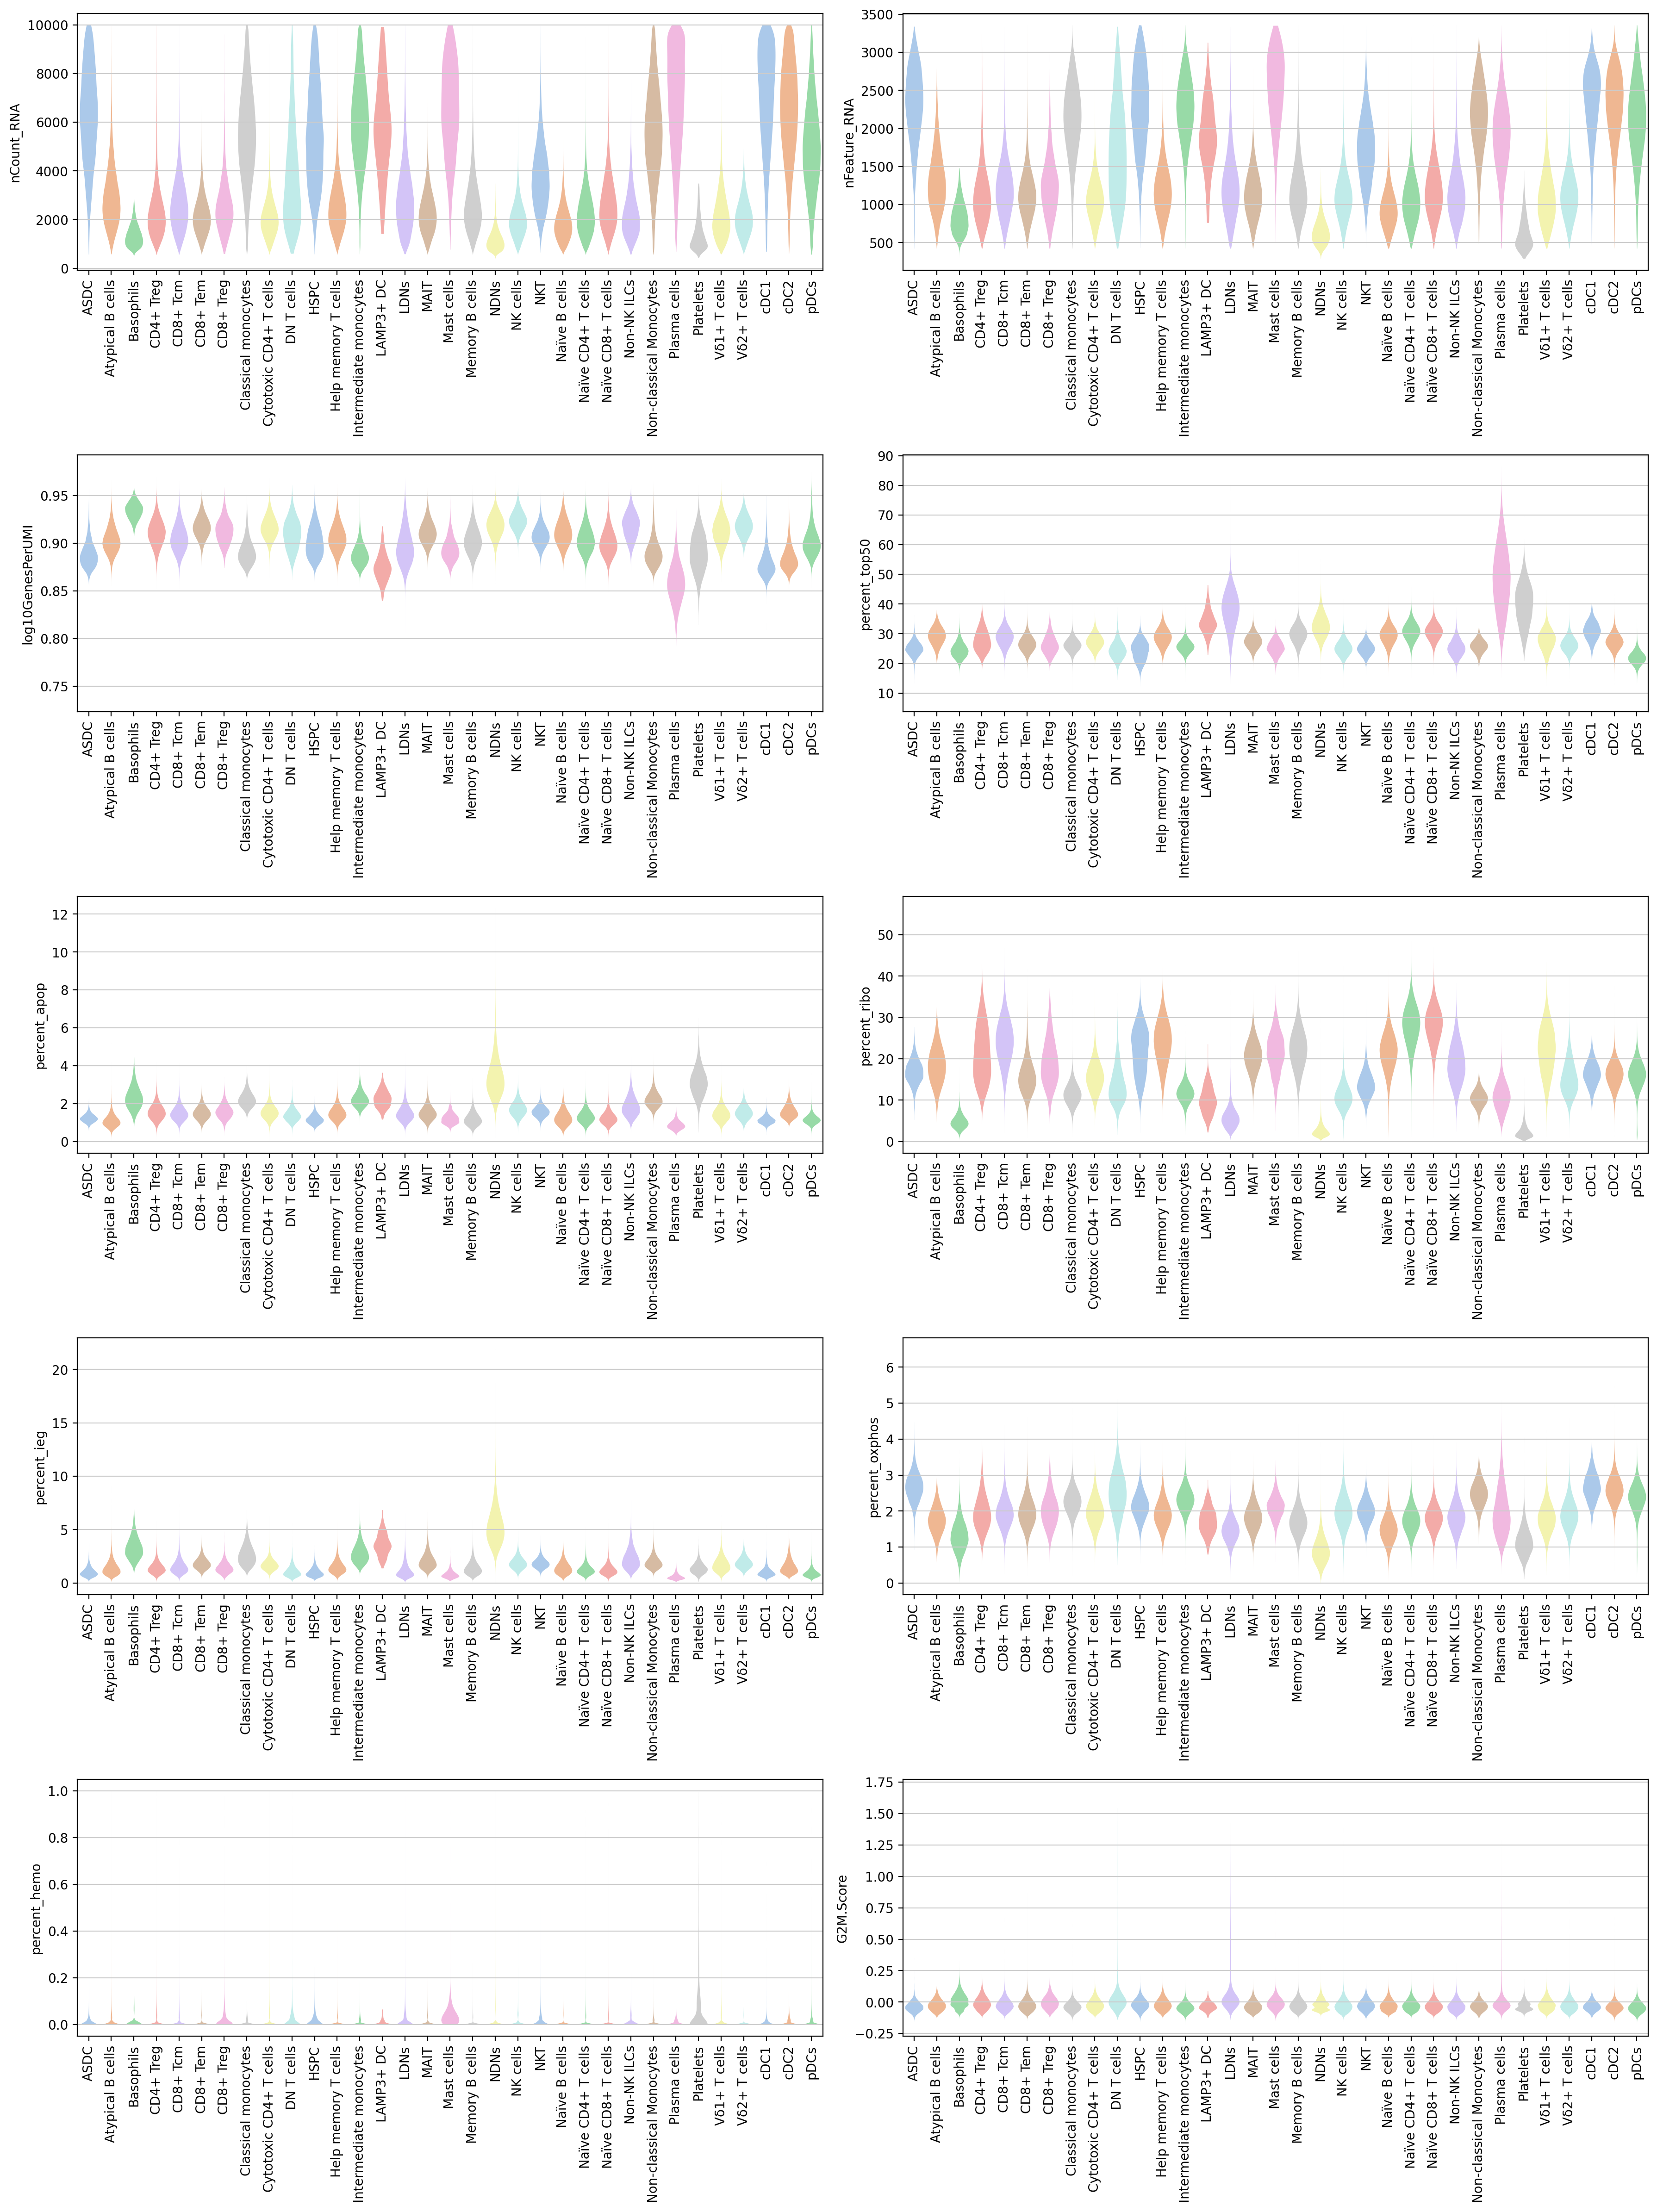

In [27]:
groupby = 'Classification_L3'

#数据簇间信息比较
fig, axs = plt.subplots(5, 2, figsize=(18, 24),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata_small, keys='nCount_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[0,0], show=False)
sc.pl.violin(adata_small, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[0,1], show=False)
sc.pl.violin(adata_small, keys='log10GenesPerUMI', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[1,0], show=False)
sc.pl.violin(adata_small, keys='percent_top50', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[1,1], show=False)

sc.pl.violin(adata_small, keys='percent_apop', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[2,0], show=False)
sc.pl.violin(adata_small, keys='percent_ribo', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[2,1], show=False)
sc.pl.violin(adata_small, keys='percent_ieg', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[3,0], show=False)
sc.pl.violin(adata_small, keys='percent_oxphos', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[3,1], show=False)
sc.pl.violin(adata_small, keys='percent_hemo', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[4,0], show=False)
sc.pl.violin(adata_small, keys='G2M.Score', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[4,1], show=False)

fig.tight_layout()
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/"
plt.savefig(f'{path}QC_metadata.png')

In [ ]:
groupby = 'Classification_L3'

#数据簇间信息比较
fig, axs = plt.subplots(figsize=(12, 5),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adata_small, keys='nCount_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[0], show=False)
sc.pl.violin(adata_small, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[1], show=False)
fig.tight_layout()
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/"
plt.savefig(f'{path}QC_metadata_small.pdf')

In [ ]:
groupby = 'Classification_L3'

#数据簇间信息比较
fig, axs = plt.subplots(figsize=(12, 5),constrained_layout=True)
plt.subplots_adjust(hspace=1,wspace=1)
sc.pl.violin(adt_small, keys='nCount_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[0], show=False)
sc.pl.violin(adt_small, keys='nFeature_RNA', groupby=groupby, rotation=90,size=0,palette="pastel",linewidth=0,ax=axs[1], show=False)
fig.tight_layout()
path = f"/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/"
plt.savefig(f'{path}QC_metadata_small.pdf')

In [28]:
del adata_small
del adt_small

# 5 Full data HVG for TOTALVI

In [7]:
adata = sc.read_h5ad('/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Full_dataset_scRNA_count.h5ad')

In [8]:
sc.pp.highly_variable_genes(adata,flavor='seurat_v3',n_top_genes=2000,subset=True)

In [9]:
adata

AnnData object with n_obs × n_vars = 51898839 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'SampleID', 'DonorID', 'percent_mito', 'percent_ribo', 'percent_mito_ribo', 'log10GenesPerUMI', 'percent_top50', 'percent_oxphos', 'percent_apop', 'percent_dna_repair', 'percent_ieg', 'percent_hemo', 'S.Score', 'G2M.Score', 'Phase', 'Reference_Atlas_L1L2_mv', 'Reference_Atlas_L1L2_pl', 'AIFI_L1', 'AIFI_L2', 'AIFI_L3', 'Immune_All_High', 'Immune_All_Low', 'Adult_Human_Blood', 'Adult_Human_Bone_marrow', 'percent.mt', 'predicted.celltype.l2.score', 'predicted.celltype.l2', 'predicted.celltype.l1.score', 'predicted.celltype.l1', 'mapping.score', 'scDblFinder.class', 'dataset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [10]:
adata.write(f'/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Full_dataset/Full_dataset_scRNA_count_HVG.h5ad',compression='gzip')

In [29]:
import session_info

session_info.show()